# ДЗ-3 — Инференс без обучения (загрузка предобученных моделей)

Этот ноутбук демонстрирует inference-only сценарий:
В нём не обучаются модели, а загружаются предобученные CatBoost/LightGBM из папки `models` и строятся прогнозы на **7 / 30 / 90** дней.

Импорты

In [12]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_theme(font_scale=1.1)

## Загрузка данных и создание объекта прогнозирования

Подготовка данных и загрузка моделей.

In [35]:
from inference_forecaster import InferenceGBForecaster

# пути до датасетов
sales = pd.read_csv("../data/shop_sales.csv")
calendar = pd.read_csv("../data/shop_sales_dates.csv")
prices = pd.read_csv("../data/shop_sales_prices.csv")

forecaster = InferenceGBForecaster(
    sales_df=sales,
    calendar_df=calendar,
    prices_df=prices,
    catboost_path="models/catboost_model.cbm",
    lightgbm_path="models/lightgbm_model.txt",
    date_col="date_id",
    target_col="cnt",
    store_col="store_id",
    store_id="STORE_2",
)

# Прогнозирование

Спрогнозируем продажи с помощью класса `InferenceGBForecaster` с предзагруженными моделями.

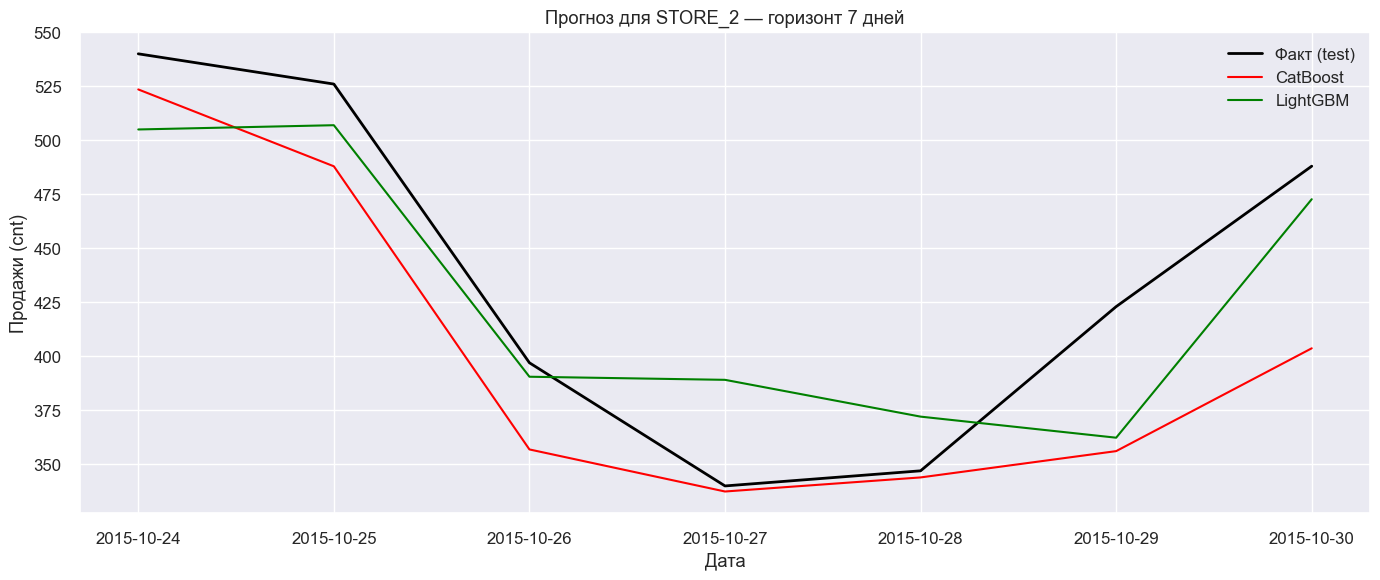

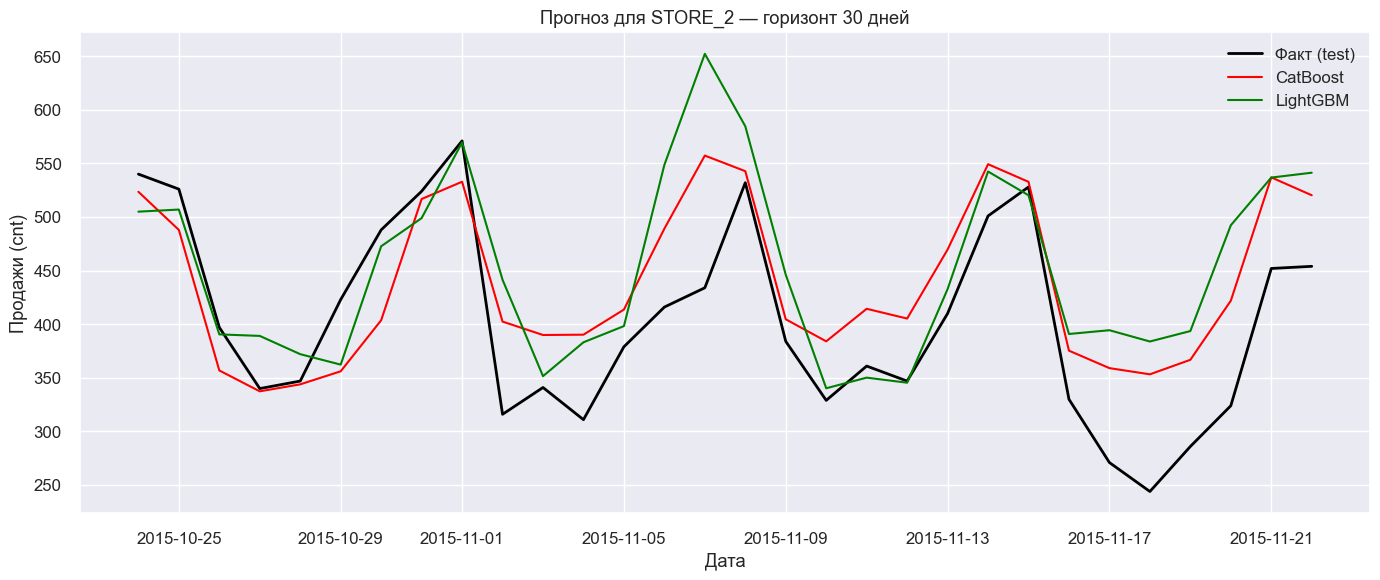

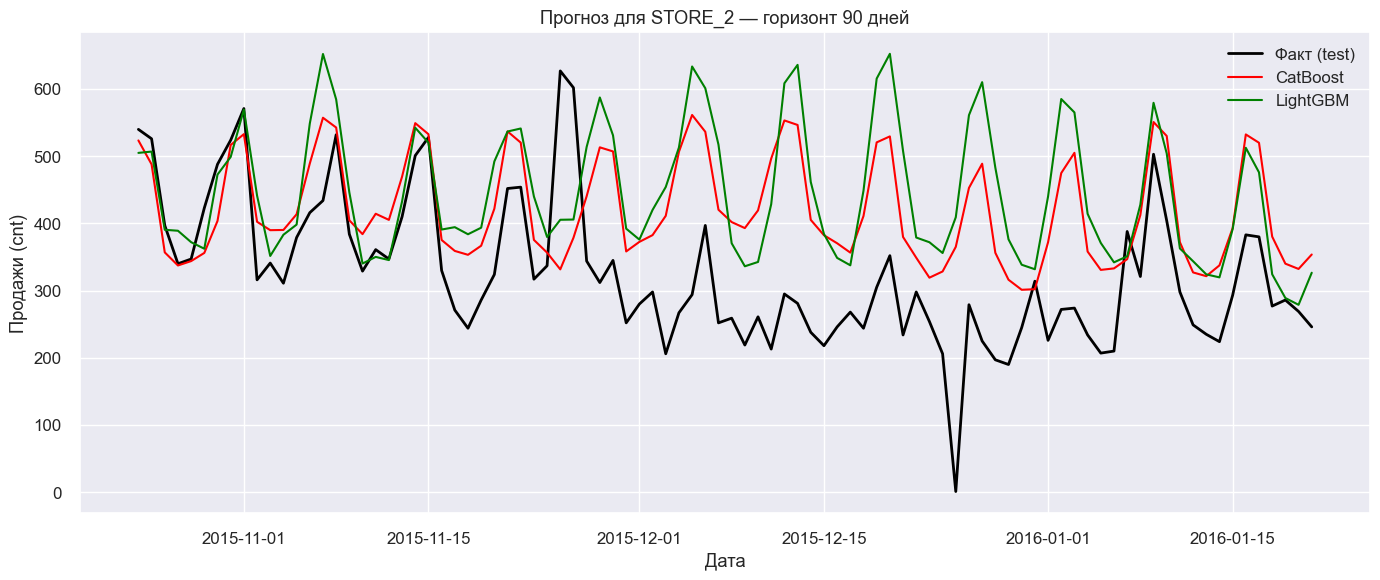

In [38]:
h = len(forecaster.test_)
fc_cat_full = forecaster.forecast(model_name="catboost", horizon=h)
fc_lightgbm_boost_full = forecaster.forecast(model_name="lightgbm", horizon=h)

horizons = [7, 30, 90]
for h in horizons:
    plt.figure(figsize=(14, 6))

    plt.plot(
        forecaster.test_.index[:h],
        forecaster.test_.values[:h],
        label="Факт (test)",
        linewidth=2,
        color="black"
    )

    plt.plot(
        fc_cat_full.index[:h],
        fc_cat_full.values[:h],
        label="CatBoost",
        color="red"
    )
    plt.plot(
        fc_lightgbm_boost_full.index[:h],
        fc_lightgbm_boost_full.values[:h],
        label="LightGBM",
        color="green"
    )

    plt.title(
        f"Прогноз для {selected_store} — горизонт {h} дней"
    )
    plt.xlabel("Дата")
    plt.ylabel("Продажи (cnt)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Оценка метрик качества

Посчитаем MAE / RMSE / MAPE для горизонтов 7, 30 и 90 дней. Для бустинга это означает рекурсивный прогноз на первые *h* дней теста.

In [40]:
horizons = [7, 30, 90]
metrics_summary = forecaster.evaluate(horizons=horizons, models=("catboost", "lightgbm"))
metrics_summary

,model,horizon,MAE,RMSE,MAPE
0,catboost,7,35.923216,2131.990538,7.873552
1,catboost,30,54.205341,3985.593015,14.974803
2,catboost,90,113.802869,18707.221660,443.300102
3,lightgbm,7,30.094981,1226.565233,7.268406
4,lightgbm,30,59.937427,6608.828405,16.877185
5,lightgbm,90,132.823998,27869.123951,499.443455


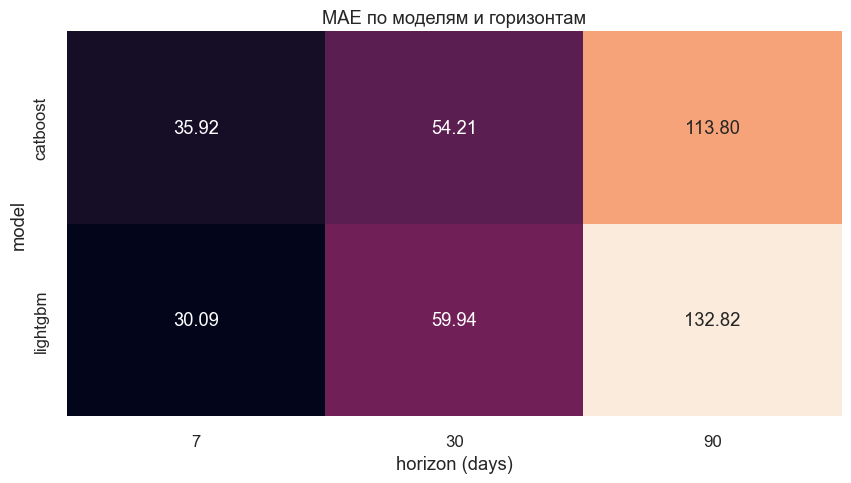

In [41]:
plt.figure(figsize=(10, 5))
pivot = metrics_summary.pivot(index="model", columns="horizon", values="MAE")
sns.heatmap(pivot, annot=True, fmt=".2f", cbar=False)
plt.title("MAE по моделям и горизонтам")
plt.xlabel("horizon (days)")
plt.ylabel("model")
plt.show()